In [1]:
%load_ext watermark


In [2]:
import os

import alifedata_phyloinformatics_convert as apc
from hstrat import _auxiliary_lib as hstrat_aux
import iplotx as ipx
import pandas as pd
from teeplot import teeplot as tp


/usr/local/lib/python3.10/dist-packages/alifedata_phyloinformatics_convert/_impl/phytrack_Systematcs.py:7: UserWarning: ImportWarning: phylotrackpy.Systematics import failed; inserting a no-op mock for Systematics. This is likely because phylotrackpy is not installed.
  warnings.warn(


In [3]:
%watermark -diwmuv -iv


Last updated: 2025-10-24T14:53:24.903189+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1036-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

alifedata_phyloinformatics_convert: 0.19.3
pandas                            : 2.2.3
hstrat                            : 1.20.16
iplotx                            : 1.2.1
teeplot                           : 1.4.2

Watermark: 2.4.3



In [4]:
teeplot_subdir = os.environ.get("NOTEBOOK_NAME", "2025-10-20-mls-strong-fossils__wse-async-ga")
teeplot_subdir


'2025-10-20-mls-strong-fossils__wse-async-ga'

## Prep Data


In [5]:
df = pd.read_parquet("https://osf.io/download/u4kzw/")


In [6]:
df = hstrat_aux.alifestd_downsample_tips_clade_asexual(df, 512)


In [7]:
df = hstrat_aux.alifestd_to_working_format(df)
df["origin_time"] = df["hstrat_rank_from_t0"]
df = hstrat_aux.alifestd_mark_origin_time_delta_asexual(df)
df.fillna({"origin_time": 0}, inplace=True)
df


,id,dstream_data_id,ancestor_id,is_extant,layer,position,genomeFlavor,globalSeed,nCol,nRow,...,fitness,tile,row,col,origin_time,hstrat_rank_from_t0,is_leaf,num_leaves,ancestor_origin_time,origin_time_delta
0,0,NaN,0,None,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,NaN,False,1186649,NaN,NaN
1,1,9.223372e+18,0,None,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,62.0,62.0,False,1186649,NaN,NaN
2,2,9.223372e+18,1,None,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,126.0,126.0,False,920469,62.0,64.0
3,3,9.223372e+18,2,None,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,254.0,254.0,False,464590,126.0,128.0
4,4,9.223372e+18,3,None,NaN,NaN,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,318.0,318.0,False,285823,254.0,64.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
966,966,3.384610e+06,965,True,NaN,NaN,genome_mls_2025_08_15,1.0,755.0,1170.0,...,2.649731,644098.0,853.0,83.0,191475.0,191475.0,True,1,191231.0,244.0
967,967,4.792710e+05,958,True,NaN,NaN,genome_mls_2025_08_15,1.0,755.0,1170.0,...,1.466058,657678.0,871.0,73.0,191513.0,191513.0,True,1,191039.0,474.0
968,968,4.930710e+05,963,True,NaN,NaN,genome_mls_2025_08_15,1.0,755.0,1170.0,...,1.616596,646338.0,856.0,58.0,191537.0,191537.0,True,1,191167.0,370.0
969,969,3.938483e+06,812,True,NaN,NaN,genome_mls_2025_08_15,1.0,755.0,1170.0,...,3.321882,634253.0,840.0,53.0,191759.0,191759.0,True,1,190335.0,1424.0


In [8]:
df["origin_time_delta"].describe()  # TODO why?


count      969.000000
mean      2617.561404
std       5563.162054
min          1.000000
25%        384.000000
50%        880.000000
75%       2475.000000
max      59393.000000
Name: origin_time_delta, dtype: float64

In [9]:
tree = apc.alife_dataframe_to_biopython_tree(
    hstrat_aux.alifestd_try_add_ancestor_list_col(df),
    setup_branch_lengths=True,
)


## Example Plot


teeplots/viz=tree+ext=.pdf
teeplots/viz=tree+ext=.png


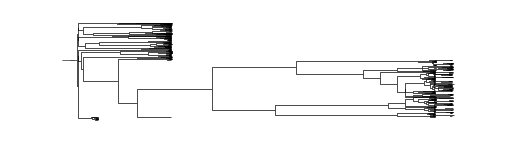

In [10]:
with tp.teed(
    ipx.plotting.tree,
    tree,
    edge_linewidth=0.5,
    ladderize=True,
    aspect=100.0,
) as teed:
    pass
